In [41]:
import json
from pathlib import Path

import numpy as np
import torch
from sklearn.metrics import brier_score_loss
from statsmodels.stats.contingency_tables import mcnemar
from torch import nn
import torch.nn.functional as F
from pytorch_lightning.loggers.tensorboard import TensorBoardLogger
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

from Model import Model, ModelParams
from TemperatureScaler import TemperatureScaler
from Datamodule import Datamodule


In [42]:
OUT_FEATURES = 10

datamodule = Datamodule()
datamodule.prepare_data()
datamodule.setup("fit")

In [43]:
CHECKPOINTS_DIR = Path("./checkpoints")
run_dates = []
for run_folder in CHECKPOINTS_DIR.iterdir():
    if run_folder.is_dir() and run_folder.name.startswith("run_"):
        run_date = run_folder.name[len("run_"):]
        run_dates.append(run_date)

run_dates = sorted(run_dates)
print(run_dates)

latest_run = run_dates[-1]
print("Latest run:", latest_run)

latest_run_dir = CHECKPOINTS_DIR/f"run_{latest_run}"
print("Latest run dir:", latest_run_dir)

['2026-06-24 13:26:58.782422', '2026-06-24 13:41:44.486169']
Latest run: 2026-06-24 13:41:44.486169
Latest run dir: checkpoints/run_2026-06-24 13:41:44.486169


In [44]:
logger = TensorBoardLogger(
    "runs",
    name="calibrate",
)

In [45]:
with open(latest_run_dir / "model_params.json", "r") as f:
    s = f.read()
    model_params = ModelParams(**json.loads(s))

model_params

ModelParams(dropout_rate=0.05, n_hidden=1, n_width=128, lr=0.001)

In [46]:
def fit_temperature(model: Model):
    scaler = TemperatureScaler(model)
    optimizer = torch.optim.LBFGS([scaler.temperature], lr=0.001, max_iter=15000)
    criterion = nn.CrossEntropyLoss()
    cal_loader = datamodule.cal_dataloader()

    all_logits = []
    all_labels = []

    with torch.no_grad():
        for X_cal, y_cal in cal_loader:
            logits = model(X_cal)
            all_logits.append(logits)
            all_labels.append(y_cal)

    all_logits = torch.cat(all_logits, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    def closure():
        optimizer.zero_grad()
        scaled_logits = scaler.scale(all_logits)
        loss = criterion(scaled_logits, all_labels)
        loss.backward()
        return loss

    optimizer.step(closure)
    return scaler

In [47]:
models = []
scalers = []
for fold_dir in latest_run_dir.iterdir():
    if not fold_dir.is_dir():
        continue

    fold = int(fold_dir.name[-1])
    model_path = next(fold_dir.iterdir())
    print(f"Model for {fold=}:", model_path)

    model = Model(fold, OUT_FEATURES, model_params)
    checkpoint_state = torch.load(model_path)
    model.load_state_dict(checkpoint_state["state_dict"])
    model.eval()
    models.append(model)

    scaler = fit_temperature(model)
    torch.save(scaler.temperature, fold_dir/"temperature.pt")

    scalers.append(scaler)

models = nn.ModuleList(models)
scalers = nn.ModuleList(scalers)

Model for fold=0: checkpoints/run_2026-06-24 13:41:44.486169/fold0/model-epoch=14-val_loss=0.242.ckpt
Model for fold=1: checkpoints/run_2026-06-24 13:41:44.486169/fold1/model-epoch=11-val_loss=0.239.ckpt
Model for fold=2: checkpoints/run_2026-06-24 13:41:44.486169/fold2/model-epoch=10-val_loss=0.244.ckpt
Model for fold=3: checkpoints/run_2026-06-24 13:41:44.486169/fold3/model-epoch=14-val_loss=0.232.ckpt
Model for fold=4: checkpoints/run_2026-06-24 13:41:44.486169/fold4/model-epoch=10-val_loss=0.249.ckpt


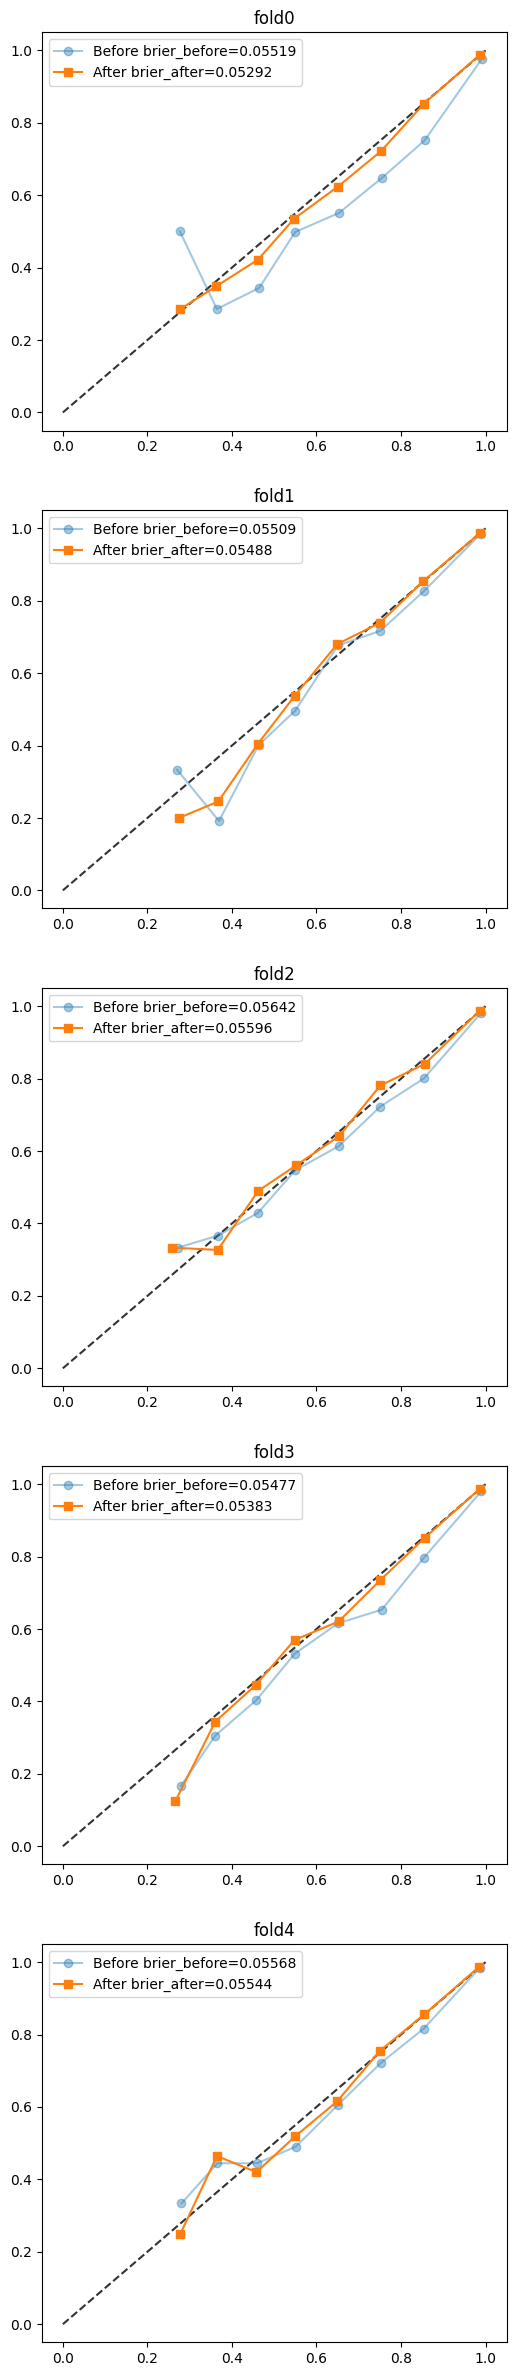

In [49]:
fig, axs = plt.subplots(5, 1, figsize=(6, 5*6))

test_loader = datamodule.test_dataloader()

for fold, (model, scaler) in enumerate(zip(models, scalers)):
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for X_cal, y_cal in test_loader:
            logits = model(X_cal)
            all_logits.append(logits)
            all_labels.append(y_cal)

    all_logits = torch.cat(all_logits, dim=0).detach()
    all_labels = torch.cat(all_labels, dim=0).detach()

    probs_before, class_before = F.softmax(all_logits, dim=1).max(dim=1)
    probs_before = probs_before.detach().numpy()
    class_before = class_before.detach().numpy()

    correct_class_before = (all_labels == class_before).detach().numpy().astype(float)

    logits_scaled = scaler.scale(all_logits)
    probs_after, class_after = F.softmax(logits_scaled, dim=1).max(dim=1)
    probs_after = probs_after.detach().numpy()
    class_after = class_after.detach().numpy()

    correct_class_after = (all_labels == class_after).numpy().astype(float)

    frac_pos_before, mean_pred_before = calibration_curve(
        correct_class_before, probs_before, n_bins=10
    )
    frac_pos_after, mean_pred_after = calibration_curve(
        correct_class_after, probs_after, n_bins=10
    )

    brier_before = brier_score_loss(correct_class_before, probs_before)
    brier_after = brier_score_loss(correct_class_after, probs_after)

    ax = axs[fold]
    ax.set_title(f"fold{fold}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.8)
    ax.plot(
        mean_pred_before,
        frac_pos_before,
        "o-",
        alpha=0.4,
        label=f"Before {brier_before=:.5f}"
    )
    ax.plot(
        mean_pred_after,
        frac_pos_after,
        "s-",
        label=f"After {brier_after=:.5f}"
    )
    ax.legend()
